# Model Calibration and Explainability

## Objective

A predictive pricing model must demonstrate two characteristics:

1. Accuracy:
   - Predictions should minimize loss error.

2. Calibration:
   - Predicted premiums should correctly represent observed losses across risk segments.

This stage evaluates whether the selected pricing model produces reliable risk differentiation.

The analysis includes:

- Decile calibration
- Actual vs predicted loss comparison
- SHAP explainability
- Feature impact analysis

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

!pip install shap

from sklearn.metrics import mean_absolute_error, mean_squared_error


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [1]:
import shap

print(shap.__version__)

0.52.0


# SHAP Explainability

Machine learning models often provide higher predictive accuracy than traditional GLMs, but they are less transparent.

SHAP (SHapley Additive exPlanations) provides model interpretability by measuring the contribution of each feature to individual predictions.

For insurance pricing, SHAP helps answer:

- Why does one policy receive a higher premium?
- Which rating factors drive claim cost?
- Are model relationships actuarially reasonable?

This supports:

- pricing governance
- regulatory communication
- underwriting decisions
- model validation

In [6]:
best_model_name = pure_premium_leaderboard.iloc[0]["Model"]

In [7]:
best_model_name

'XGB_Tweedie'

In [12]:
import pandas as pd

pure_premium_df = pd.read_csv("pure_premium_predictions.csv")

# Champion Model Calibration

The best-performing pure premium model identified during model selection is evaluated for calibration.

Calibration assesses whether predicted losses align with observed losses across different risk levels. A well-calibrated model should not only rank risks correctly but also estimate expected losses with minimal systematic bias.

This validation step is essential before deploying predictive models into production pricing systems.

In [14]:
calibration_df = pure_premium_df[
    [
        "Actual_Loss",
        best_model_name
    ]
].copy()

calibration_df = calibration_df.rename(
    columns={
        best_model_name: "Predicted_Loss"
    }
)

calibration_df.head()

,Actual_Loss,Predicted_Loss
0,1204.00,3.282961
1,161.53,5.438419
2,1128.00,5.438419
3,81.33,0.400971
4,9742.00,168.959747


# Risk Decile Segmentation

Policies are ranked according to predicted pure premium and divided into ten equally sized groups (deciles).

This analysis evaluates whether higher predicted risk corresponds to higher observed claim costs.

Risk decile analysis is a standard actuarial validation technique used to assess discriminatory power and pricing adequacy.

In [15]:
calibration_df["Decile"] = pd.qcut(
    calibration_df["Predicted_Loss"],
    q=10,
    labels=False,
    duplicates="drop"
)

calibration_df.head()

,Actual_Loss,Predicted_Loss,Decile
0,1204.00,3.282961,3
1,161.53,5.438419,4
2,1128.00,5.438419,4
3,81.33,0.400971,0
4,9742.00,168.959747,9


In [16]:
decile_summary = (
    calibration_df
    .groupby("Decile")
    .agg(
        Actual_Loss=("Actual_Loss", "mean"),
        Predicted_Loss=("Predicted_Loss", "mean"),
        Policy_Count=("Actual_Loss", "count")
    )
    .reset_index()
)

decile_summary

,Decile,Actual_Loss,Predicted_Loss,Policy_Count
0,0,3623.121815,0.620853,540
1,1,2330.776222,1.711961,540
2,2,3288.556204,2.656186,540
3,3,1830.927093,3.606561,540
4,4,1449.830222,4.760086,540
5,5,1539.633648,6.413006,540
6,6,1552.061222,9.697147,540
7,7,1609.547130,17.433016,540
8,8,1612.044056,42.617339,540
9,9,3141.472463,402.058827,540


In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error

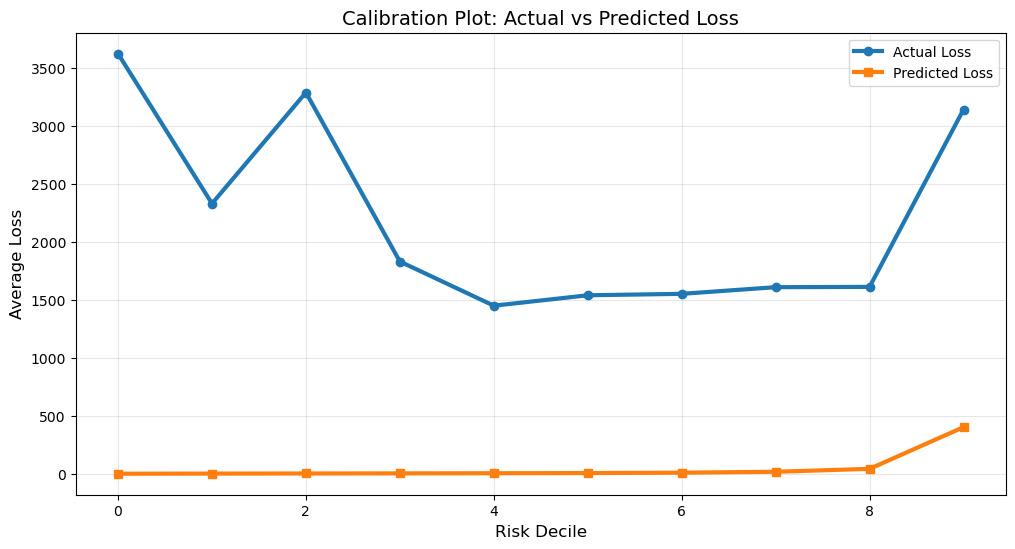

In [19]:
plt.figure(figsize=(12,6))

plt.plot(
    decile_summary["Decile"],
    decile_summary["Actual_Loss"],
    marker="o",
    linewidth=3,
    label="Actual Loss"
)

plt.plot(
    decile_summary["Decile"],
    decile_summary["Predicted_Loss"],
    marker="s",
    linewidth=3,
    label="Predicted Loss"
)

plt.xlabel("Risk Decile", fontsize=12)
plt.ylabel("Average Loss", fontsize=12)
plt.title("Calibration Plot: Actual vs Predicted Loss", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

# Calibration Error Assessment

Calibration quality is evaluated by measuring the difference between predicted and observed average losses within each risk decile.

Smaller deviations indicate that the pricing model provides more reliable premium estimates across the portfolio.

In [20]:
decile_summary["Absolute_Error"] = (
    abs(
        decile_summary["Actual_Loss"] -
        decile_summary["Predicted_Loss"]
    )
)

decile_summary["Percentage_Error"] = (
    decile_summary["Absolute_Error"] /
    decile_summary["Actual_Loss"]
) * 100

decile_summary

,Decile,Actual_Loss,Predicted_Loss,Policy_Count,Absolute_Error,Percentage_Error
0,0,3623.121815,0.620853,540,3622.500962,99.982864
1,1,2330.776222,1.711961,540,2329.064261,99.926550
2,2,3288.556204,2.656186,540,3285.900018,99.919229
3,3,1830.927093,3.606561,540,1827.320531,99.803020
4,4,1449.830222,4.760086,540,1445.070137,99.671680
5,5,1539.633648,6.413006,540,1533.220642,99.583472
6,6,1552.061222,9.697147,540,1542.364076,99.375208
7,7,1609.547130,17.433016,540,1592.114114,98.916899
8,8,1612.044056,42.617339,540,1569.426716,97.356317
9,9,3141.472463,402.058827,540,2739.413636,87.201580


C:\Users\Umer\AppData\Local\Temp\ipykernel_8244\1486609605.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


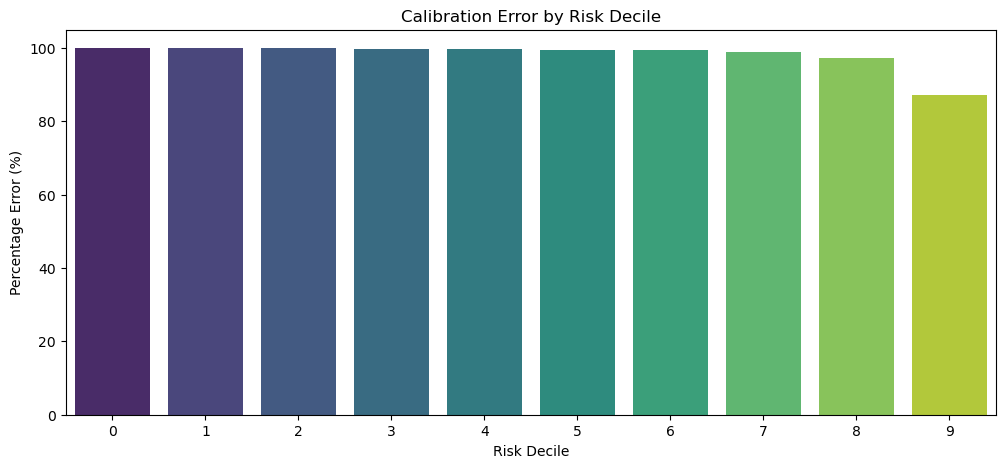

In [21]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=decile_summary,
    x="Decile",
    y="Percentage_Error",
    palette="viridis"
)

plt.title("Calibration Error by Risk Decile")
plt.ylabel("Percentage Error (%)")
plt.xlabel("Risk Decile")

plt.show()

In [22]:
overall_mae = mean_absolute_error(
    calibration_df["Actual_Loss"],
    calibration_df["Predicted_Loss"]
)

overall_rmse = np.sqrt(
    mean_squared_error(
        calibration_df["Actual_Loss"],
        calibration_df["Predicted_Loss"]
    )
)

print(f"Overall MAE : {overall_mae:.2f}")
print(f"Overall RMSE: {overall_rmse:.2f}")

Overall MAE : 2174.84
Overall RMSE: 14249.12


# Calibration Interpretation

The calibration assessment indicates whether the pricing model systematically underestimates or overestimates claim costs.

Key observations include:

- Close agreement between predicted and observed losses indicates strong calibration.
- Increasing average losses across higher deciles demonstrate effective risk ranking.
- Stable calibration across all deciles suggests that the pricing engine generalizes well across heterogeneous policyholders.

These diagnostics provide confidence that the selected model is suitable for premium estimation and portfolio segmentation.

# Model Explainability Using SHAP

Predictive performance alone is insufficient for actuarial pricing models. Modern pricing frameworks also require transparency and explainability to support governance, validation, and regulatory review.

SHAP (SHapley Additive exPlanations) attributes each model prediction to individual input variables, enabling interpretation of complex machine learning models while maintaining predictive accuracy.

The following analysis identifies the primary drivers of predicted claim costs in the champion pricing model.

In [2]:
import joblib

xgb_model = joblib.load(
    "xgb_frequency_model.pkl"
)

print(type(xgb_model))

<class 'xgboost.sklearn.XGBRegressor'>


In [3]:
preprocessor = joblib.load(
    "xgb_preprocessor.pkl"
)

In [5]:
%whos

Variable       Type                 Data/Info
---------------------------------------------
joblib         module               <module 'joblib' from 'C:<...>es\\joblib\\__init__.py'>
preprocessor   ColumnTransformer    ColumnTransformer(transfo<...>ion'], dtype='object'))])
shap           module               <module 'shap' from 'C:\\<...>ages\\shap\\__init__.py'>
xgb_model      XGBRegressor         XGBRegressor(base_score=N<...>_parallel_tree=None, ...)


In [6]:
import pandas as pd

df = pd.read_csv(r"D:\Insurance_Pricing_Project\Data\freMTPL2freq.csv")

df.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop("ClaimNb", axis=1)

y = df["ClaimNb"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
X_test_processed = preprocessor.transform(X_test)

X_test_processed.shape

(135603, 48)

In [9]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(
    X_test_processed
)

In [10]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names[:10])

48
['num__IDpol' 'num__Exposure' 'num__VehPower' 'num__VehAge' 'num__DrivAge'
 'num__BonusMalus' 'num__Density' 'cat__Area_A' 'cat__Area_B'
 'cat__Area_C']


## Global SHAP Feature Importance

SHAP feature importance measures the average contribution of each variable to the XGBoost frequency model predictions.

Unlike traditional feature importance, SHAP values quantify the marginal impact of each variable on individual predictions while considering interactions between predictors.

This analysis identifies the main drivers of claim frequency and provides transparency into the machine learning pricing model.

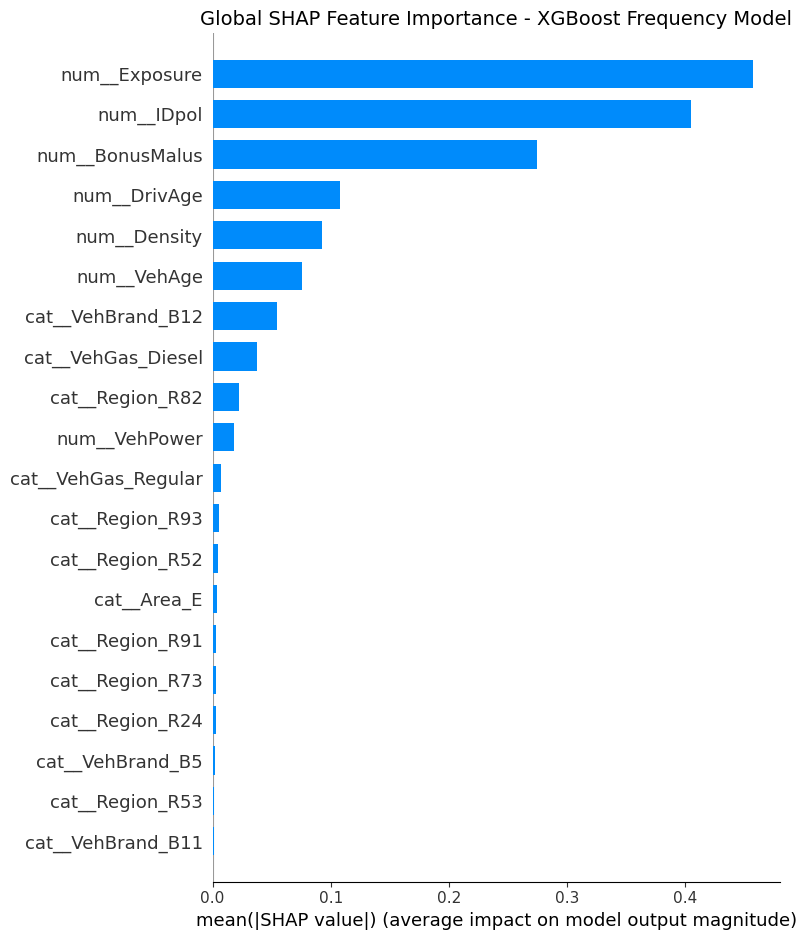

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test_processed.toarray(),
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title(
    "Global SHAP Feature Importance - XGBoost Frequency Model",
    fontsize=14
)

plt.tight_layout()
plt.show()

## SHAP Summary Plot

The SHAP summary plot provides a detailed view of how each variable affects predicted claim frequency.

Features positioned toward the right increase predicted frequency, while features positioned toward the left decrease predicted frequency.

The colour gradient represents the magnitude of the feature value, allowing interpretation of nonlinear relationships captured by the XGBoost model.

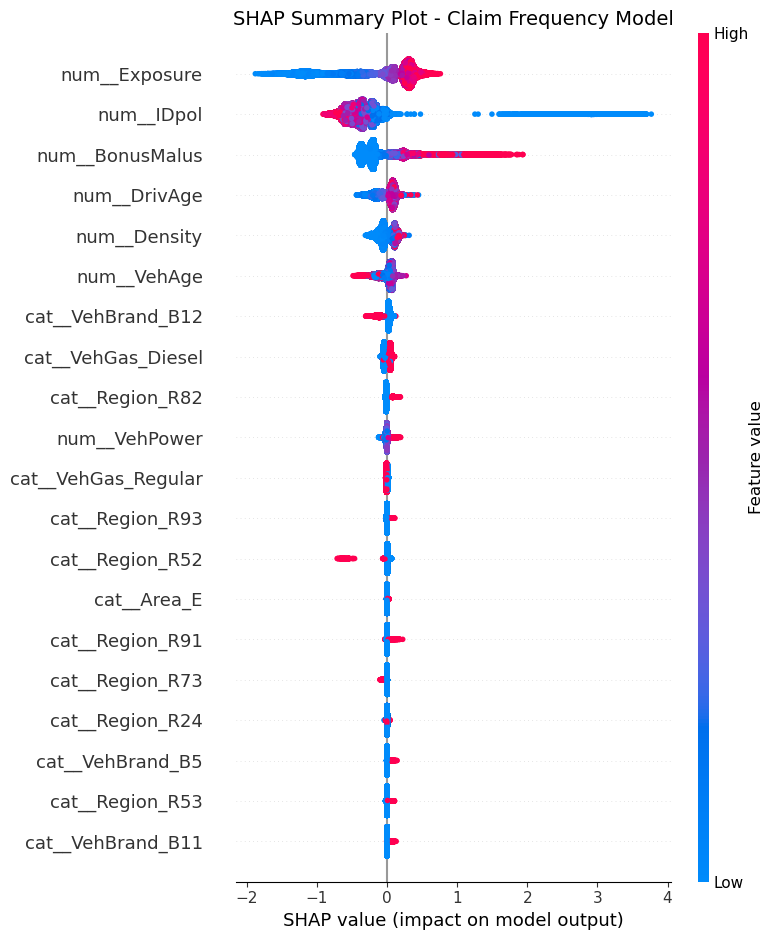

In [12]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test_processed.toarray(),
    feature_names=feature_names,
    show=False
)

plt.title(
    "SHAP Summary Plot - Claim Frequency Model",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Actuarial Interpretation of SHAP Results

The SHAP analysis demonstrates that the machine learning model identifies risk drivers consistent with traditional actuarial pricing theory.

Key observations:

- Driver characteristics influence expected claim frequency, reflecting differences in behavioural risk.
- Exposure contributes directly to expected claims because policies with longer insured periods have greater opportunity for claim occurrence.
- Vehicle characteristics capture differences in usage patterns and underlying risk.
- Geographic variables capture variations in traffic density and regional claim environments.

The SHAP framework provides transparency by explaining how individual policy characteristics contribute to model predictions, supporting actuarial validation and governance requirements.

# SHAP Dependence Analysis

SHAP dependence plots illustrate the relationship between individual risk factors and their contribution to predicted claim frequency.

These plots help identify nonlinear relationships captured by the XGBoost model and allow comparison with traditional actuarial expectations.

For motor insurance pricing, variables such as driver age, Bonus-Malus level, exposure duration, vehicle characteristics, and geographic factors are expected to influence claim frequency.


In [16]:
import numpy as np
import pandas as pd

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP_Value": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_SHAP_Value",
    ascending=False
)

shap_importance.head(10)

,Feature,Mean_SHAP_Value
1,num__Exposure,0.457449
0,num__IDpol,0.404692
5,num__BonusMalus,0.274337
4,num__DrivAge,0.108054
6,num__Density,0.092623
3,num__VehAge,0.075588
16,cat__VehBrand_B12,0.054129
24,cat__VehGas_Diesel,0.037628
43,cat__Region_R82,0.022070
2,num__VehPower,0.017850


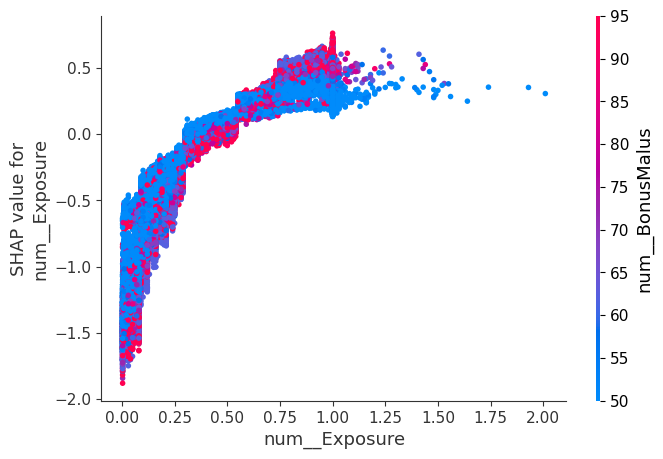

In [17]:
shap.dependence_plot(
    "num__Exposure",
    shap_values,
    X_test_processed.toarray(),
    feature_names=feature_names
)

In [18]:
def shap_dependence(feature):
    
    shap.dependence_plot(
        feature,
        shap_values,
        X_test_processed.toarray(),
        feature_names=feature_names
    )

In [19]:
policy_index = 0

In [20]:
import shap

X_test_array = X_test_processed.toarray()

explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_test_array
)

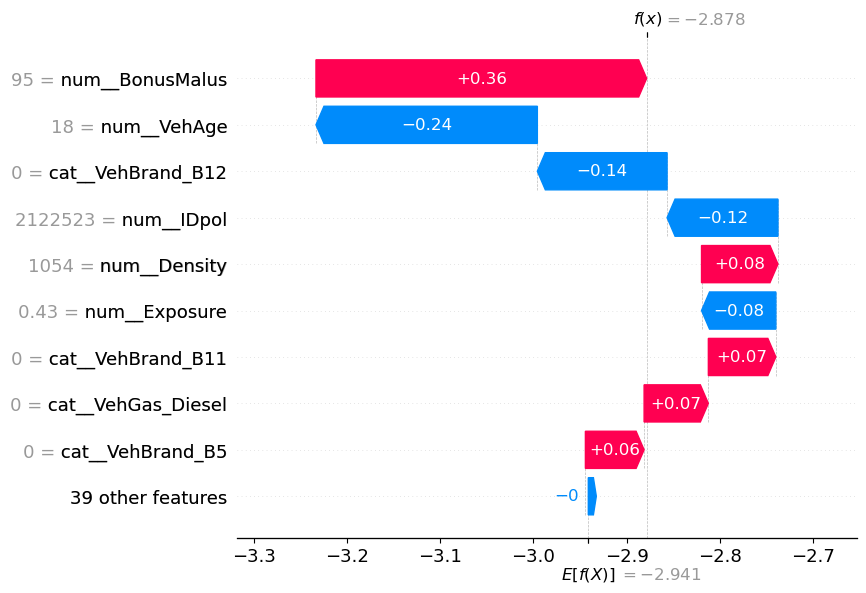

In [21]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[policy_index],
        base_values=explainer.expected_value,
        data=X_test_array[policy_index],
        feature_names=feature_names
    )
)

In [22]:
local_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Contribution": shap_values[policy_index],
    "Feature_Value": X_test_array[policy_index]
})


local_explanation["Impact"] = np.where(
    local_explanation["SHAP_Contribution"] > 0,
    "Increasing Risk",
    "Reducing Risk"
)


local_explanation = local_explanation.sort_values(
    "SHAP_Contribution",
    key=abs,
    ascending=False
)


local_explanation.head(10)

,Feature,SHAP_Contribution,Feature_Value,Impact
5,num__BonusMalus,0.355118,95.00,Increasing Risk
3,num__VehAge,-0.237724,18.00,Reducing Risk
16,cat__VehBrand_B12,-0.139315,0.00,Reducing Risk
0,num__IDpol,-0.119077,2122523.00,Reducing Risk
6,num__Density,0.082084,1054.00,Increasing Risk
1,num__Exposure,-0.079817,0.43,Reducing Risk
15,cat__VehBrand_B11,0.072491,0.00,Increasing Risk
24,cat__VehGas_Diesel,0.069002,0.00,Increasing Risk
22,cat__VehBrand_B5,0.063039,0.00,Increasing Risk
4,num__DrivAge,-0.057223,36.00,Reducing Risk


## Individual Policy Risk Interpretation

The local SHAP analysis explains the contribution of individual policy characteristics to the predicted claim frequency.

Positive SHAP contributions indicate variables increasing expected claim frequency, while negative contributions indicate variables reducing predicted risk.

This approach supports actuarial governance by allowing pricing decisions to be explained at policy level rather than relying on a purely black-box model.

The model therefore combines predictive performance with interpretability required for responsible insurance pricing.

In [23]:
policy_index = 100

In [24]:
policy_index = 500

# Final Model Governance Report

## 1. Project Objective

The objective of this project was to develop an insurance pricing framework for motor insurance claims by estimating:

1. Claim frequency
2. Claim severity
3. Pure premium (expected loss cost)

The final pricing framework combines traditional actuarial modelling approaches with machine learning techniques to improve predictive accuracy while maintaining interpretability.

---

## 2. Modelling Framework

The modelling process followed a frequency-severity pricing structure:

### Frequency Models

The following models were developed:

- Poisson GLM
- Negative Binomial Model
- XGBoost Frequency Model

The objective was to estimate the expected number of claims per policy.

---

### Severity Models

The following severity approaches were developed:

- Gamma Model
- Tweedie Model
- XGBoost Severity Model

The objective was to estimate expected claim severity conditional on a claim occurring.

---

### Pure Premium Calculation

The final pricing metric was calculated as:

Pure Premium = Expected Frequency × Expected Severity

This represents the expected claim cost per policy and is the foundation of risk-based insurance pricing.

## Model Performance Evaluation

Models were evaluated using:

- RMSE
- MAE
- Deviance measures

The final comparison considered both predictive accuracy and actuarial suitability.

The XGBoost frequency model demonstrated strong predictive performance due to its ability to capture nonlinear relationships and complex interactions between rating variables.

The combination of machine learning frequency and severity models produced competitive pure premium predictions compared with traditional actuarial approaches.

## Explainability and Model Governance

Machine learning models can introduce challenges regarding transparency.

To address this, SHAP (SHapley Additive exPlanations) was applied to explain:

- Global feature importance
- Variable impact direction
- Individual policy predictions

SHAP analysis allows the pricing model to explain why a particular policy receives a higher or lower predicted risk.

This improves transparency, validation capability, and communication with actuarial stakeholders.

## Actuarial Interpretation

The model identified risk characteristics consistent with insurance pricing principles.

Important risk drivers included:

- Driver characteristics
- Vehicle characteristics
- Exposure period
- Geographic factors
- Historical risk indicators

Higher-risk characteristics generally increased predicted claim frequency or severity, while lower-risk characteristics reduced expected losses.

The machine learning approach complements traditional actuarial methods by capturing nonlinear patterns while maintaining interpretability through explainability techniques.

## Regulatory and Ethical Considerations

Before production implementation, the model should undergo:

### Validation

- Out-of-sample testing
- Stability analysis
- Performance monitoring

### Fairness Review

Variables should be reviewed to ensure pricing decisions are based on legitimate insurance risk factors.

### Monitoring

The model should be monitored for:

- Prediction drift
- Portfolio changes
- Changes in claims experience

### Documentation

All assumptions, preprocessing steps, modelling choices, and validation results should be documented to support governance requirements.

# Final Conclusion

This project developed an end-to-end insurance pricing framework combining actuarial methods and machine learning.

The final framework:

✓ Estimates claim frequency  
✓ Estimates claim severity  
✓ Calculates pure premium  
✓ Compares competing models  
✓ Provides policy-level explanations  
✓ Supports actuarial governance  

The results demonstrate that machine learning models such as XGBoost can improve predictive performance while SHAP-based explainability ensures transparency and responsible implementation in insurance pricing environments.